In [15]:
#importing all the necessary libraries
#for handling the data
import pandas as pd
import numpy as np

#for plotting graphs
import seaborn as sns
import matplotlib.pyplot as plt

#ML Models

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# **Schema Details:**

Customer ID: ID of the customers

Gender: Gender of the customer

Age: Age of the customers

Annual Income: Annual Income of the customers

Spending Score: How often a person spends money in a mall on a scale of 1 to 100

In [16]:
#Read CSV
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **Checking the size of data**

In [17]:
#Check Shape
df.shape

(200, 5)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Now checking if our data has high variability

After the results below, we can see for all the attriutes **Variance** is far away from **mean** and mean > STD. This concludes that our data has high Variability

In [19]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# **Data Cleaning**

Doing mandatory checks, checking if our data has any nulls to perform cleaning.

No Null and duplicate data found, so proceeding to next STEP.

In [20]:
#check if any null values in data
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [21]:
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

Accoding to Bar graph, we can see there are more number of **Female** customers than **Male** customers

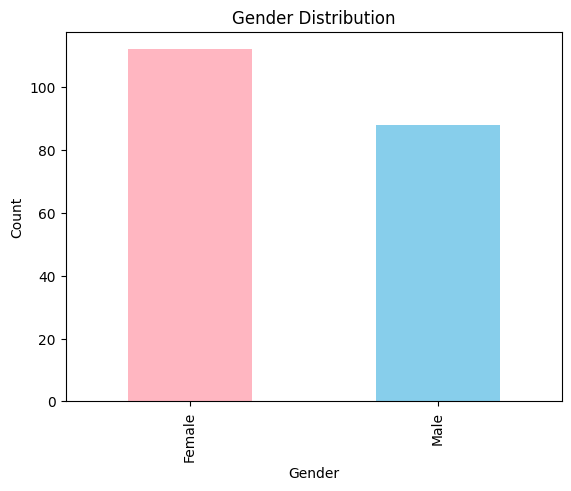

In [22]:
#Distribution of gender

df["Gender"].value_counts().plot(kind="bar", color=["lightpink", "skyblue"] )
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Analysis of Gender % of gender present

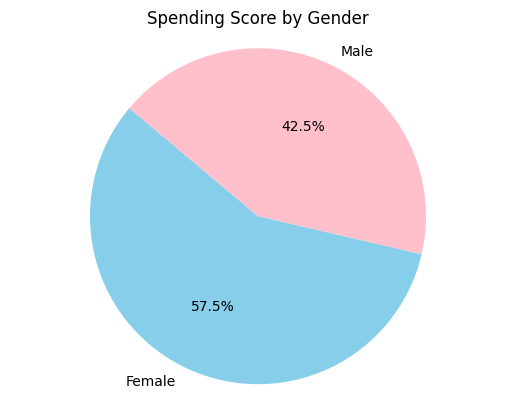

In [23]:
# Aggregate spending score by gender
gender_spending = df.groupby('Gender')['Spending Score (1-100)'].sum()

# Creating pie chart
plt.pie(gender_spending.values, labels=gender_spending.index, colors=['skyBlue', 'pink'],autopct='%1.1f%%', startangle=140)
plt.title('Spending Score by Gender')
 # This will ensure pie is drawn in circle
plt.axis('equal')
plt.show()

Below Observation shows the **Age Distribution** across the data.

*   Most of the spenders are Middle Aged (30-40)
*   There are wide range of people from 20 to 70 who are spending their Money




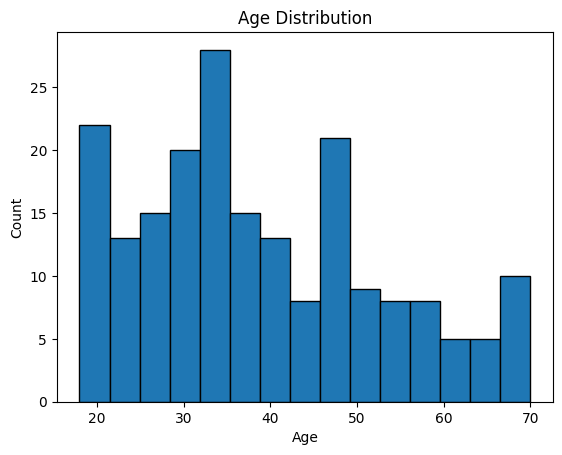

In [24]:
#Age Distribution

plt.hist(df["Age"], bins=15, edgecolor = "black", linewidth = 1)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


*   Most of the annual income falls between 50k to 85k


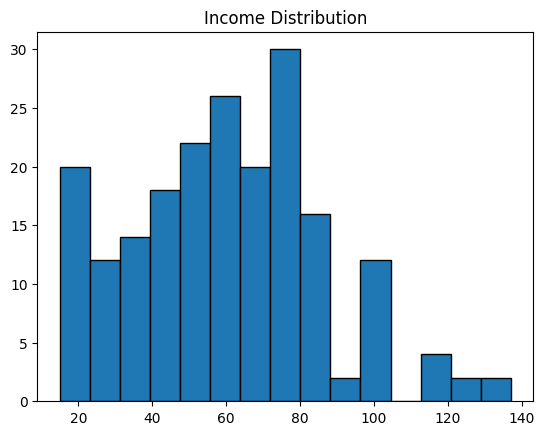

In [25]:
#income Distribution

plt.hist(df["Annual Income (k$)"], bins=15, edgecolor = "black", linewidth = 1)
plt.title("Income Distribution")
plt.show()

*   The maximum spending score is in the range of 40 to 60

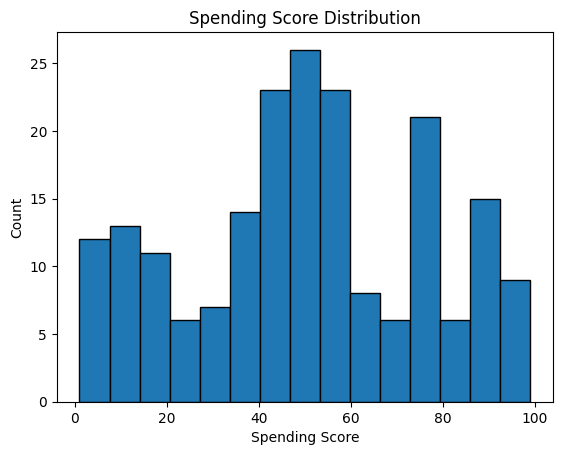

In [26]:
#Spending Score Distribution

plt.hist(df["Spending Score (1-100)"], bins=15, edgecolor = "black", linewidth = 1)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

# **Income Vs Spending**

From the scatter plot we can see, how the clusters are formed and we can thus understand the behaviour of the data

This is one of the most important plots for customer segmentation.

It can show groups like:

High income + high spending

High income + low spending

Low income + high spending

Low income + low spending

Average income + average spending

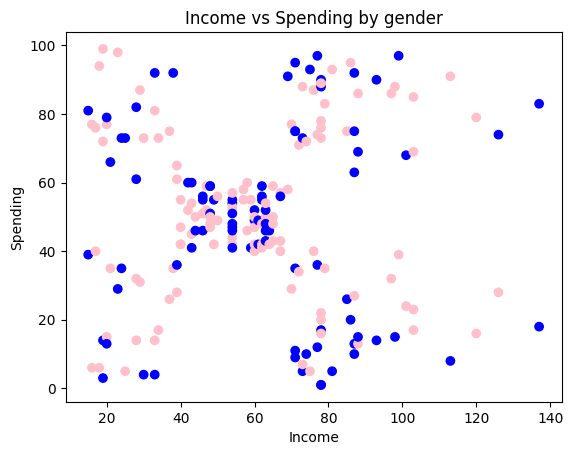

In [27]:
colors = df["Gender"].map({"Male": "blue", "Female": "pink"})
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=colors)
plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Income vs Spending by gender")
plt.show()

# **Age VS Spending Score**

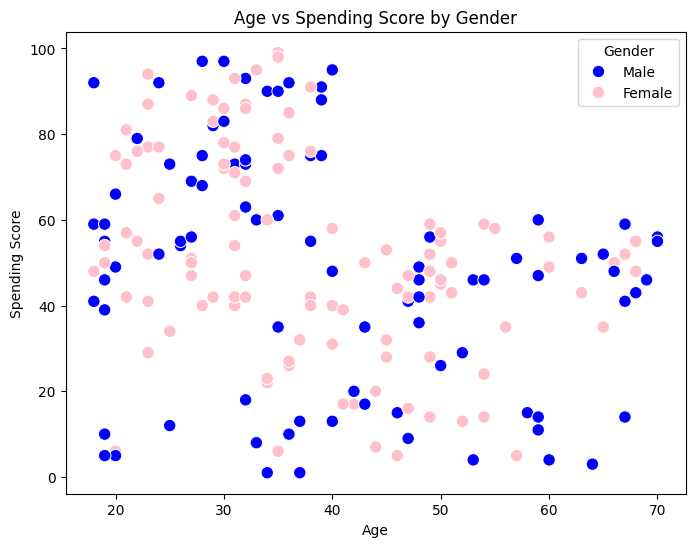

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="Age",y="Spending Score (1-100)", hue="Gender",
    palette={"Male": "blue", "Female": "pink"},
    s=80
)
plt.title("Age vs Spending Score by Gender")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.show()

# **Pairs Plot to understand behavior**

By below plot we can see, out of all data, females are the ones whose spending score more in malls

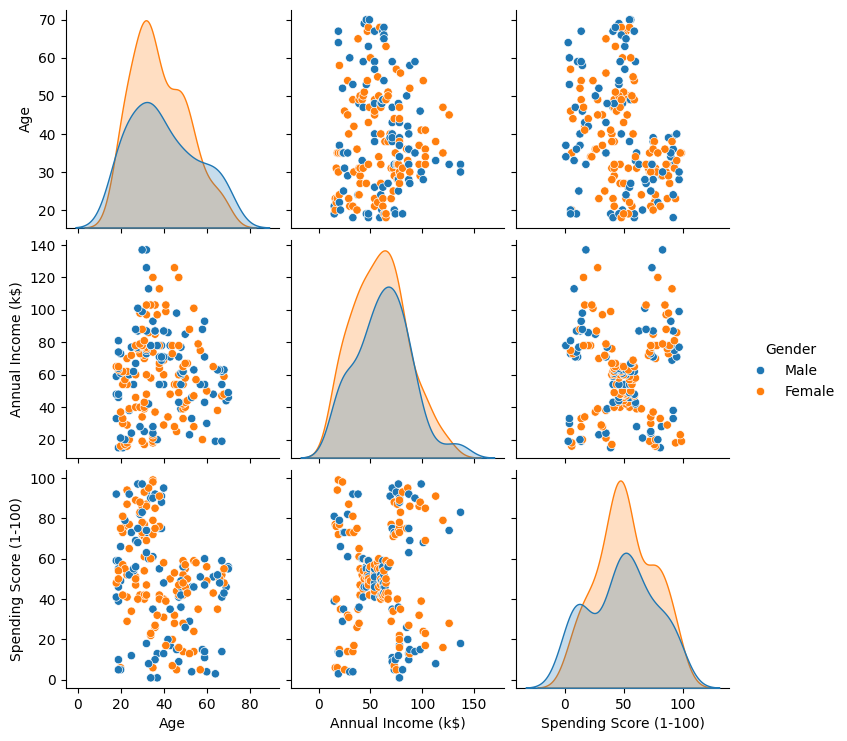

In [29]:
sns.pairplot(df.drop('CustomerID', axis = 1), hue="Gender")
plt.show()

# **Gender Wise Spending Score**


Female customers show a slightly wider spread, meaning their spending behavior is more varied compared to males.

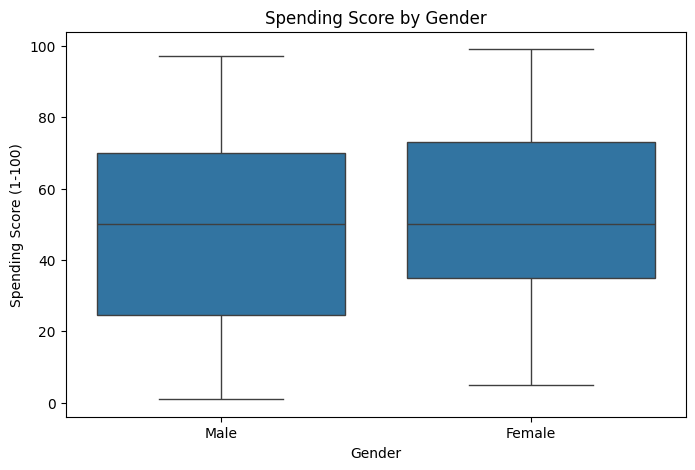

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Gender",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Spending Score by Gender")
plt.show()

# **Correlation**

In [31]:
#calculate correlation

corr_matrix = df[["Age","Annual Income (k$)","Spending Score (1-100)"]].corr()


from the below heatmap, the only positive relation is between **annual income** and **spending score**, so lets use those attributes for our further implementation for segmentation using few models

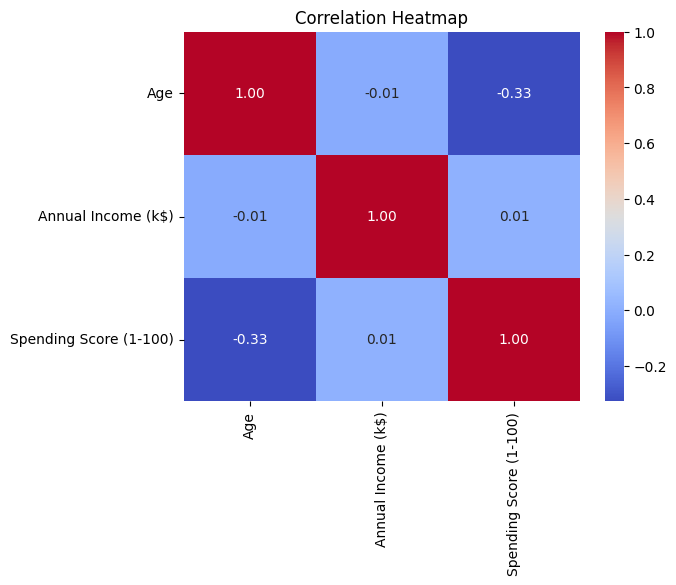

In [32]:
# Visualize the correlation matrix using a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')  # 'annot=True' shows correlation coefficients
plt.title('Correlation Heatmap')
plt.show()

# **Data Preparation**

Gender is categorical variable and cannot be used for implementation, so converting categorical variables into numerical

In [33]:
#drop customer ID as it is used as an indicator
df_model = df.drop("CustomerID", axis=1)
df_model["Gender"] = df_model["Gender"].map({"Male":0, "Female":1})
X=df_model
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


# **K Means Clustering**

In [34]:
#considering only positively correlated attriutes
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


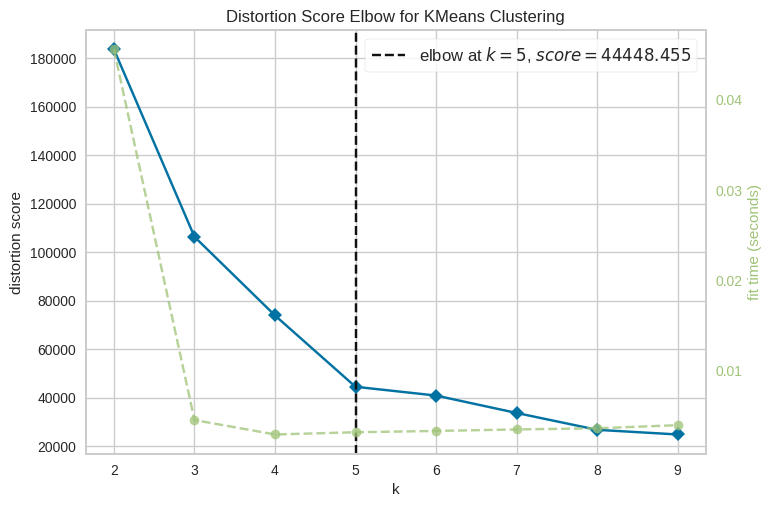

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [35]:
#Finding the value of K

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2,10))

visualizer.fit(X)
visualizer.show()

In [36]:
kmeans=KMeans(n_clusters=5, init = 'k-means++', random_state = 42)
KMeans_Cluster = kmeans.fit_predict(X)
df_clustered = df.copy()
df_clustered['KMeans_Cluster'] = KMeans_Cluster
df_clustered.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


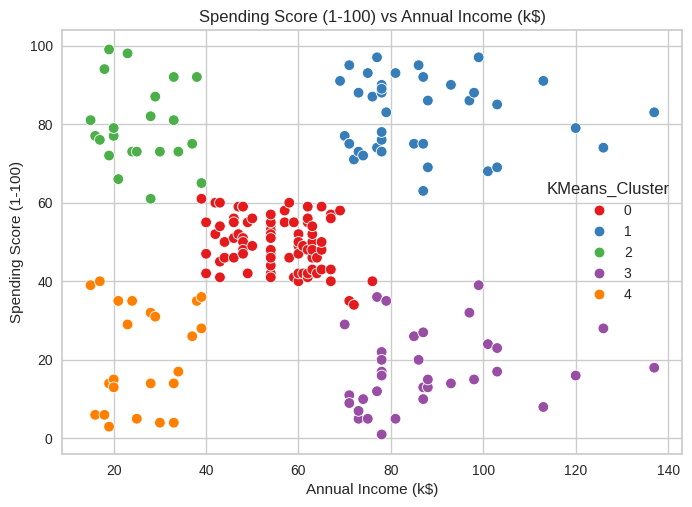

In [37]:
sns.scatterplot(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',hue="KMeans_Cluster",
                 palette='Set1', data = df_clustered, s = 60 )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.show()


In [38]:
# Group the data by cluster to find out mean of all attributes and count in each cluster

cluster_stats = df_clustered.groupby('KMeans_Cluster').agg({'Annual Income (k$)': 'mean', 'Spending Score (1-100)': 'mean', 'CustomerID': 'count'})
cluster_stats = cluster_stats.rename(columns={'Annual Income (k$)': 'Average income annually (k$)', 'Spending Score (1-100)': 'Average Spending Score (1-100)', 'CustomerID': 'Count'})
print(cluster_stats)

                Average income annually (k$)  Average Spending Score (1-100)  \
KMeans_Cluster                                                                 
0                                  55.296296                       49.518519   
1                                  86.538462                       82.128205   
2                                  25.727273                       79.363636   
3                                  88.200000                       17.114286   
4                                  26.304348                       20.913043   

                Count  
KMeans_Cluster         
0                  81  
1                  39  
2                  22  
3                  35  
4                  23  


# **K Means Clustering - 3 features**

In [39]:
#considering only positively correlated attriutes
X_3features = df[['Annual Income (k$)', 'Spending Score (1-100)','Age']]
X_3features.head()

,Annual Income (k$),Spending Score (1-100),Age
0,15,39,19
1,15,81,21
2,16,6,20
3,16,77,23
4,17,40,31


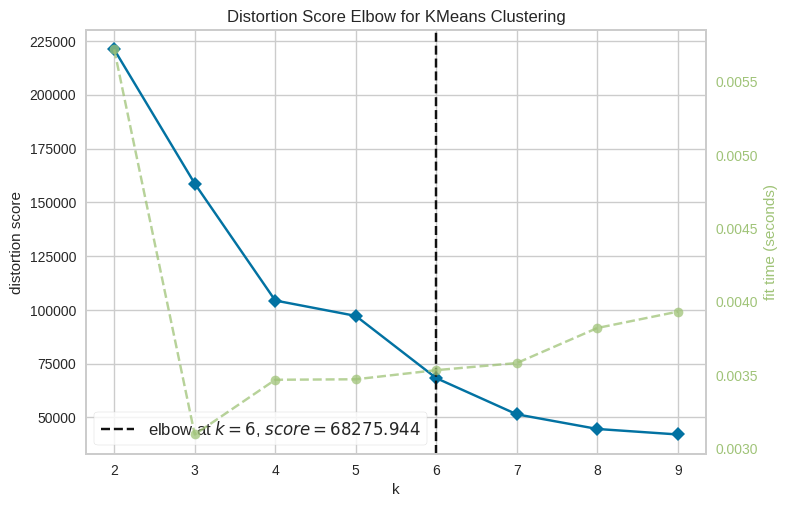

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [40]:
#Finding the value of K

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2,10))

visualizer.fit(X_3features)
visualizer.show()

In [41]:
kmeans=KMeans(n_clusters=6, init = 'k-means++', random_state = 42)
KMeans_Cluster_3features = kmeans.fit_predict(X_3features)
df_clustered_3feature = df.copy()
df_clustered_3feature['KMeans_Cluster_3features'] = KMeans_Cluster_3features
df_clustered_3feature.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster_3features
0,1,Male,19,15,39,5
1,2,Male,21,15,81,2
2,3,Female,20,16,6,5
3,4,Female,23,16,77,2
4,5,Female,31,17,40,5


By the graph below, here's what we can conclude,

Cluster 1 - High income, high spending (VIP customers)

Cluster 3 - High income, low spending (target customers)

Cluster 2 - Low income, high spending (impulsive buyers)

Cluster 4 - Low income, low spending (budget customers)

Cluster 0 - Average income, average spending (regular customers)

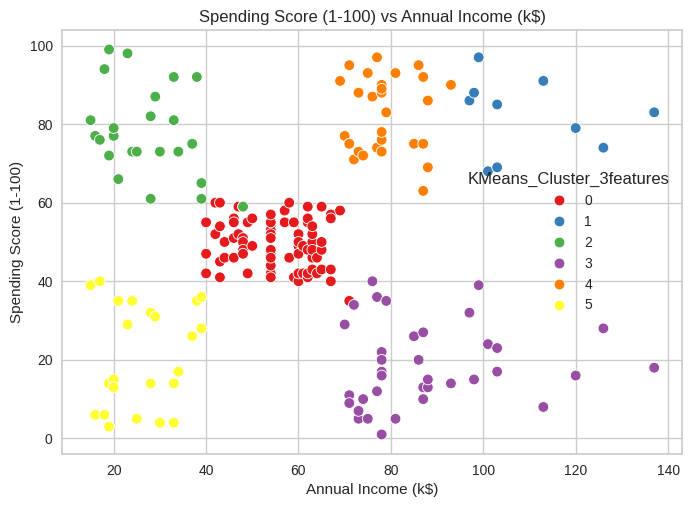

In [42]:
sns.scatterplot(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',hue="KMeans_Cluster_3features",
                 palette='Set1', data = df_clustered_3feature, s = 60 )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.show()


In [43]:
# Group the data by cluster to find out mean of all attributes and count in each cluster

cluster_stats = df_clustered_3feature.groupby('KMeans_Cluster_3features').agg({'Annual Income (k$)': 'mean', 'Spending Score (1-100)': 'mean', 'CustomerID': 'count'})
cluster_stats = cluster_stats.rename(columns={'Annual Income (k$)': 'Average income annually (k$)', 'Spending Score (1-100)': 'Average Spending Score (1-100)', 'CustomerID': 'Count'})
print(cluster_stats)

                          Average income annually (k$)  \
KMeans_Cluster_3features                                 
0                                            55.210526   
1                                           109.700000   
2                                            28.040000   
3                                            87.432432   
4                                            78.551724   
5                                            26.304348   

                          Average Spending Score (1-100)  Count  
KMeans_Cluster_3features                                         
0                                              49.447368     76  
1                                              82.000000     10  
2                                              77.000000     25  
3                                              18.189189     37  
4                                              82.172414     29  
5                                              20.913043     23  


In [44]:
score_2_features = silhouette_score(X, KMeans_Cluster)
score_3_features = silhouette_score(X_3features, KMeans_Cluster_3features)
print("Silhouette Score for 2 features:", score_2_features)
print("Silhouette Score for 3 features:", score_3_features)

Silhouette Score for 2 features: 0.553931997444648
Silhouette Score for 3 features: 0.4155672337697055


# **Hierarchial Clustering**

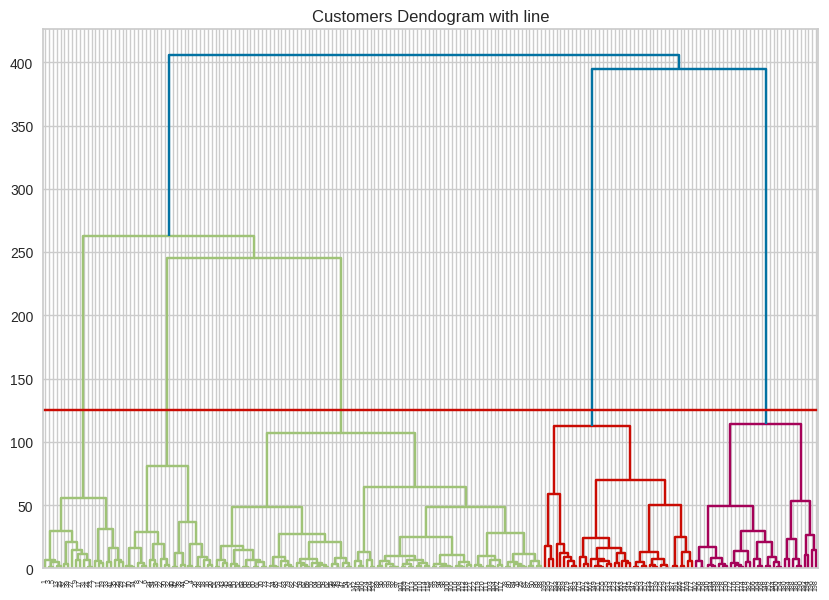

In [45]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
plt.title("Customers Dendogram with line")
clusters = shc.linkage(X,
            method='ward',
            metric="euclidean")
shc.dendrogram(clusters)
plt.axhline(y = 125, color = 'r')

# **Agglomerative Hierarchial Clustering**

In [46]:
from sklearn.cluster import AgglomerativeClustering

clustering_model = AgglomerativeClustering(n_clusters=5, metric = 'euclidean',linkage = 'ward')
clustering_model.fit(X)
clustering_model.labels_


array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

Text(0.5, 1.0, 'Agglomerative clustering of customers')

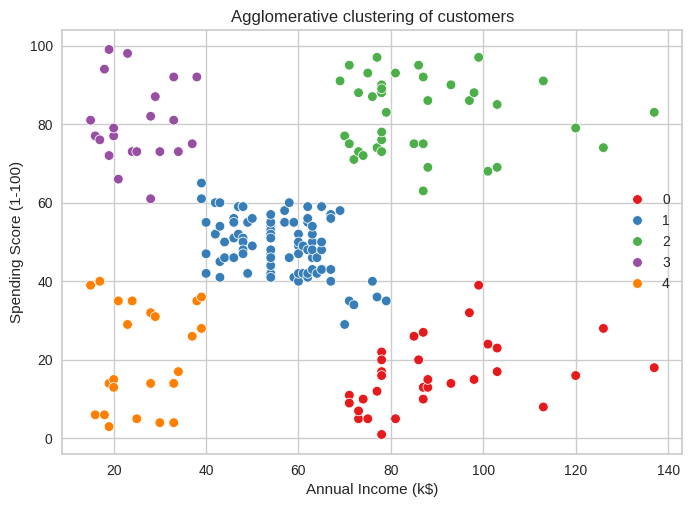

In [47]:
data_labels = clustering_model.labels_
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=X,
                hue=data_labels,
                palette="Set1").set_title('Agglomerative clustering of customers')

# **Gaussian Mixture Model (GMM)**

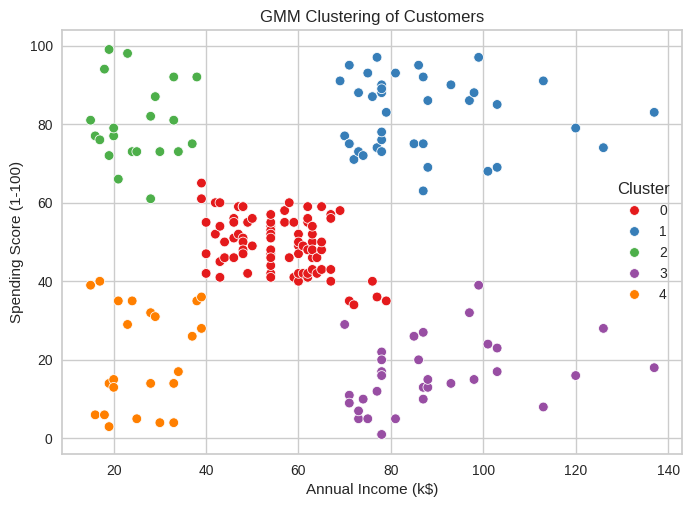

In [48]:
#Fit a Gaussian Mixture Model (GMM)
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X)

#Assign cluster labels
clusters = gmm.predict(X)

df_clustered2 = df.copy()
#Add cluster labels to the DataFrame
df_clustered2['Cluster'] = clusters

#Visualize the clusters
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_clustered2, palette='Set1')
plt.title('GMM Clustering of Customers')
plt.show()

Calculate silhouette score to see which model is performing better

KMeans Score: 0.519981674755675
Agglomerative Score: 0.5529945955148897
GMM Score: 0.5528243704895652


# **DBSCAN**

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

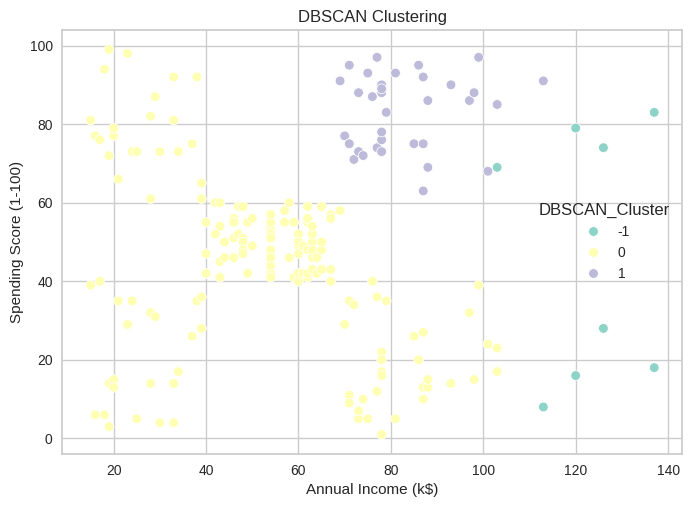

In [52]:
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="DBSCAN_Cluster",
    palette="Set3",
    data=df
)
plt.title("DBSCAN Clustering")
plt.show()

#Mean Shift

Estimated Bandwidth: 1.046673351189705
Number of clusters: 3
Cluster labels: [0 1 2]


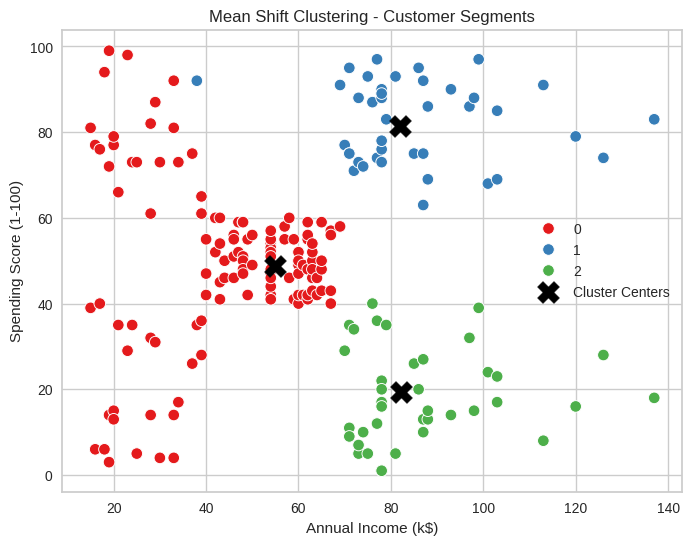

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth

df = pd.read_csv("Mall_Customers.csv")

features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Scale the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Estimate bandwidth

bandwidth = estimate_bandwidth(
    X_scaled,
    quantile=0.2,
    n_samples=len(X_scaled)
)

print("Estimated Bandwidth:", bandwidth)


#  Apply Mean Shift clustering

mean_shift = MeanShift(bandwidth=bandwidth,bin_seeding=True)

labels_ms = mean_shift.fit_predict(X_scaled)


# Cluster details

n_clusters = len(np.unique(labels_ms))

print("Number of clusters:", n_clusters)
print("Cluster labels:", np.unique(labels_ms))

# Convert cluster centers back to original scale
centers_original = scaler.inverse_transform(mean_shift.cluster_centers_)

# Plot graph
plt.figure(figsize=(8, 6))

sns.scatterplot(x=df['Annual Income (k$)'],y=df['Spending Score (1-100)'],hue=labels_ms,palette='Set1',s=70)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker='X',
    s=250,
    c='black',
    label='Cluster Centers'
)

plt.title('Mean Shift Clustering - Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [56]:
# Calculate silhouette score

print("KMeans Score:", silhouette_score(X, kmeans.labels_))
print("Agglomerative Score:", silhouette_score(X, clustering_model.labels_))
print("GMM Score:", silhouette_score(X, clusters))
print("Mean Shift Score:", silhouette_score(X_scaled, labels_ms))

KMeans Score: 0.519981674755675
Agglomerative Score: 0.5529945955148897
GMM Score: 0.5528243704895652
Mean Shift Score: 0.46411524135728593
